### 多项式回归实战-天猫销量预测【双十一】

#### 创造数据

In [137]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge

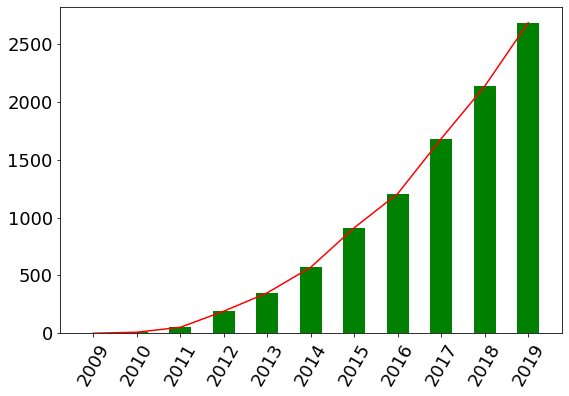

In [138]:
import numpy as np
from sklearn.linear_model import SGDRegressor

import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18
plt.figure(figsize=(9,6))

# 创建数据，年份数据2009 ~ 2019
X = np.arange(2009,2020) # 一维
# 天猫双十一销量
y = np.array([0.5,9.36,52,191,350,571,912,1207,1682,2135,2684])

plt.bar(X,y,width = 0.5,color = 'green') # 条形图
plt.plot(X,y,color = 'red') # 线形图
_ = plt.xticks(ticks = X,rotation = 60) # X轴刻度，设置成2009 - 2019

#### 将数据X进行转换

In [139]:
display(X.shape)
X = X.reshape(-1,1)
display(X.shape)

(11,)

(11, 1)

In [140]:
X

array([[2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019]])

#### 特征工程

In [141]:
# 如果没有这一步，无法拟合的
X -= np.int32(X.mean())
X # 1 表示2009,11 表示2019,12表示2020

array([[-5],
       [-4],
       [-3],
       [-2],
       [-1],
       [ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5]])

#### 升维处理

In [142]:
np.set_printoptions(suppress=True) # 科学计数法，就不显示

In [143]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3,include_bias=False)# 不包含截距

X = poly.fit_transform(X)
display(X)

array([[  -5.,   25., -125.],
       [  -4.,   16.,  -64.],
       [  -3.,    9.,  -27.],
       [  -2.,    4.,   -8.],
       [  -1.,    1.,   -1.],
       [   0.,    0.,    0.],
       [   1.,    1.,    1.],
       [   2.,    4.,    8.],
       [   3.,    9.,   27.],
       [   4.,   16.,   64.],
       [   5.,   25.,  125.]])

#### 归一化【算法中，包含梯度下降，都需要归一化】

In [144]:
# from sklearn.preprocessing import MinMaxScaler

# mm = MinMaxScaler()

# # 归一化后的数据
# X = mm.fit_transform(X)
# X

In [145]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

X = standard.fit_transform(X)
X

array([[-1.58113883,  1.69841555, -2.04670663],
       [-1.26491106,  0.67936622, -1.0479138 ],
       [-0.9486833 , -0.1132277 , -0.44208863],
       [-0.63245553, -0.67936622, -0.13098922],
       [-0.31622777, -1.01904933, -0.01637365],
       [ 0.        , -1.13227703,  0.        ],
       [ 0.31622777, -1.01904933,  0.01637365],
       [ 0.63245553, -0.67936622,  0.13098922],
       [ 0.9486833 , -0.1132277 ,  0.44208863],
       [ 1.26491106,  0.67936622,  1.0479138 ],
       [ 1.58113883,  1.69841555,  2.04670663]])

#### SGD建模

In [146]:
model = SGDRegressor(fit_intercept=True,max_iter=5000,eta0=0.5)

# 以往的数据，2009 到 2019
model.fit(X,y)# 建模

d:\soft\python\396\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1503: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDRegressor(eta0=0.5, max_iter=5000)

#### 算法验证【效果】

In [147]:
X_test = np.linspace(-5,6).reshape(-1,1) # 1表示2009，12表示2020
X_test = poly.fit_transform(X_test)

# 直接使用transform，相当于使用数据X的平均值和标准差，作为归一化的计算指标
X_test = standard.transform(X_test) # 直接使用standard进行转换
X_test

array([[-1.58113883,  1.69841555, -2.04670663],
       [-1.51014892,  1.4499371 , -1.78321996],
       [-1.43915902,  1.21287101, -1.54337668],
       [-1.36816911,  0.9872173 , -1.32606535],
       [-1.2971792 ,  0.77297596, -1.13017453],
       [-1.2261893 ,  0.57014699, -0.95459278],
       [-1.15519939,  0.3787304 , -0.79820866],
       [-1.08420948,  0.19872617, -0.65991073],
       [-1.01321958,  0.03013432, -0.53858754],
       [-0.94222967, -0.12704516, -0.43312765],
       [-0.87123976, -0.27281227, -0.34241963],
       [-0.80024986, -0.40716701, -0.26535202],
       [-0.72925995, -0.53010938, -0.20081339],
       [-0.65827004, -0.64163937, -0.1476923 ],
       [-0.58728014, -0.741757  , -0.10487731],
       [-0.51629023, -0.83046225, -0.07125696],
       [-0.44530032, -0.90775513, -0.04571983],
       [-0.37431042, -0.97363564, -0.02715447],
       [-0.30332051, -1.02810377, -0.01444944],
       [-0.2323306 , -1.07115954, -0.00649329],
       [-0.1613407 , -1.10280293, -0.002

In [148]:
# 算法根据以往的双十一销售规律，进行的预测
y_ = model.predict(X_test)
y_

array([   1.82650397,   -2.74419311,   -4.47003797,   -3.34175019,
          0.64995067,    7.51434503,   17.26071332,   29.89833598,
         45.43649344,   63.88446611,   85.25153445,  109.54697886,
        136.78007979,  166.96011766,  200.0963729 ,  236.19812595,
        275.27465723,  317.33524717,  362.3891762 ,  410.44572476,
        461.51417326,  515.60380215,  572.72389185,  632.8837228 ,
        696.09257541,  762.35973012,  831.69446737,  904.10606757,
        979.60381117, 1058.19697858, 1139.89485025, 1224.70670659,
       1312.64182805, 1403.70949504, 1497.91898801, 1595.27958737,
       1695.80057356, 1799.49122701, 1906.36082815, 2016.41865741,
       2129.67399521, 2246.136122  , 2365.81431819, 2488.71786422,
       2614.85604051, 2744.23812751, 2876.87340563, 3012.77115531,
       3151.94065697, 3294.39119105])

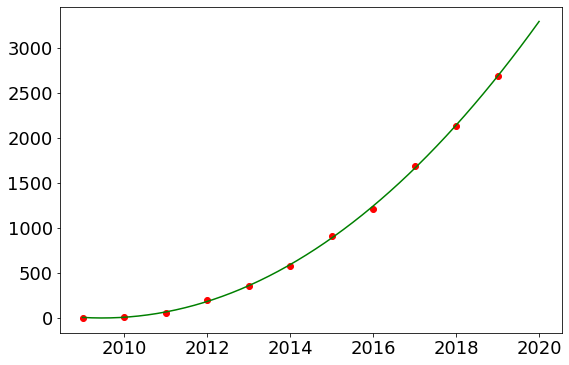

In [149]:
plt.figure(figsize=(9,6))
plt.scatter(np.arange(2009,2020),y,color = 'red')

plt.plot(np.linspace(2009,2020),y_,color = 'green')

### 逻辑斯蒂回归使用

In [150]:
# 存在于这个linear_model中，说明逻辑斯蒂回归和线性回归，有关系！！
# 逻辑斯蒂回归内部，是一个线性回归模型 + sigmoid函数，进行概率的转化
# 概率 0 到 1 根据数字的大小，分类 设置阈值 < 0.5 甲类，大于等于 0.5 乙类
# 关键：逻辑斯蒂回归用于解决分类问题
# 逻辑斯蒂回归，名字虽然带着回归，不可以解决回归问题，它是一个分类算法
# 老婆饼，没有老婆
# 红烧狮子头，有狮子吗？
from sklearn.linear_model import LogisticRegression # 逻辑斯蒂回归

#### sigmoid曲线绘制

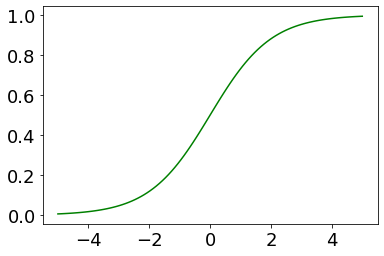

In [151]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(x):
    return 1/(1 + np.exp(-x))
x = np.linspace(-5,5,100)
y = sigmoid(x)
plt.plot(x,y,color = 'green')

### 逻辑斯蒂回归分类

In [152]:
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_iris

#### 加载数据

In [153]:
X,y = load_iris(return_X_y=True)
display(X.shape,y)

(150, 4)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

#### 拆分

In [154]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15) # 15%保留作为测试数据
display(X_train.shape,X_test.shape)

(127, 4)

(23, 4)

#### 建模

In [155]:
model = LogisticRegression(max_iter=1000) # 默认的参数使100，没有拟合好，提升参数的次数

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

#### 预测

In [156]:
y_ = model.predict(X_test)
display('真实类别：',y_test)
display('算法预测：',y_)

'真实类别：'

array([0, 2, 1, 1, 2, 1, 1, 0, 2, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 2, 1,
       0])

'算法预测：'

array([0, 2, 1, 1, 1, 2, 1, 0, 2, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 2, 1,
       0])

In [157]:
model.score(X_test,y_test)

0.9130434782608695

#### 概率

In [158]:
model.predict_proba(X_test)

array([[0.97754451, 0.02245546, 0.00000003],
       [0.00002269, 0.03559619, 0.96438111],
       [0.00778803, 0.89474849, 0.09746348],
       [0.08136146, 0.91461311, 0.00402542],
       [0.01008948, 0.57484769, 0.41506283],
       [0.00355854, 0.41223687, 0.58420459],
       [0.02465211, 0.91150878, 0.06383912],
       [0.98561179, 0.01438818, 0.00000003],
       [0.00012086, 0.11913934, 0.88073979],
       [0.94966947, 0.05033035, 0.00000017],
       [0.07361101, 0.92094118, 0.00544781],
       [0.96690091, 0.033099  , 0.00000009],
       [0.97475356, 0.02524637, 0.00000007],
       [0.0334601 , 0.94945181, 0.01708809],
       [0.29283985, 0.70573553, 0.00142462],
       [0.98448304, 0.01551693, 0.00000003],
       [0.00328052, 0.8273788 , 0.16934068],
       [0.01448564, 0.73721358, 0.24830079],
       [0.0000299 , 0.13491685, 0.86505325],
       [0.98040689, 0.01959306, 0.00000005],
       [0.00000227, 0.03042016, 0.96957758],
       [0.01065964, 0.92680796, 0.0625324 ],
       [0.

#### 方程，线性回归方程

In [159]:
w_=model.coef_

In [165]:
b_ = model.intercept_
b_

array([  9.99194245,   2.65965726, -12.65159971])

In [161]:
w_

array([[-0.45604417,  0.81521403, -2.38355513, -0.97404674],
       [ 0.44558855, -0.41502772, -0.14455525, -0.99933968],
       [ 0.01045561, -0.40018631,  2.52811037,  1.97338642]])

In [177]:
z= X_test.dot(w_.T) + b_
def softmax(x):
    return np.e**x/((np.e**x).sum(axis = 1)).reshape(-1,1)
softmax(z)

array([[0.97754451, 0.02245546, 0.00000003],
       [0.00002269, 0.03559619, 0.96438111],
       [0.00778803, 0.89474849, 0.09746348],
       [0.08136146, 0.91461311, 0.00402542],
       [0.01008948, 0.57484769, 0.41506283],
       [0.00355854, 0.41223687, 0.58420459],
       [0.02465211, 0.91150878, 0.06383912],
       [0.98561179, 0.01438818, 0.00000003],
       [0.00012086, 0.11913934, 0.88073979],
       [0.94966947, 0.05033035, 0.00000017],
       [0.07361101, 0.92094118, 0.00544781],
       [0.96690091, 0.033099  , 0.00000009],
       [0.97475356, 0.02524637, 0.00000007],
       [0.0334601 , 0.94945181, 0.01708809],
       [0.29283985, 0.70573553, 0.00142462],
       [0.98448304, 0.01551693, 0.00000003],
       [0.00328052, 0.8273788 , 0.16934068],
       [0.01448564, 0.73721358, 0.24830079],
       [0.0000299 , 0.13491685, 0.86505325],
       [0.98040689, 0.01959306, 0.00000005],
       [0.00000227, 0.03042016, 0.96957758],
       [0.01065964, 0.92680796, 0.0625324 ],
       [0.